# PR17 · Separate denoising, Gibbs removal, eddy correction and interpolation

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Identify different artifact models instead of labeling all processing “cleaning.”
- See what low-rank denoising keeps and discards.
- Recognize Gibbs ringing and why pipeline order affects assumptions.

## Understand the operation

Diffusion preprocessing combines operations aimed at different mechanisms. Thermal noise, magnitude noise-floor effects, ringing from finite sampling, susceptibility distortion, eddy-current distortion, movement and intensity bias are not interchangeable. One attractive-looking output cannot prove all have been removed. The method and its assumptions have to match acquisition and downstream modeling.

MP-PCA denoising estimates signal/noise structure from local redundant diffusion measurements using a random-matrix model. Our truncated-SVD demonstration shares the low-rank idea but does not implement MP-PCA’s noise estimation or patch logic. Interpolation before a noise estimator can introduce correlations that violate its assumed noise structure. Conversely, a chosen rank that is too small can delete meaningful orientation-dependent signal. Averaging all diffusion volumes erases the contrast used to fit diffusion models, so it is not a general denoising strategy.

Gibbs ringing is an oscillatory consequence of limited Fourier representation near sharp boundaries. Its appearance is distinct from independent random noise, and acquisition choices such as partial Fourier affect applicability of correction methods. The second toy intentionally truncates high-frequency coefficients of a step image to expose overshoot and undershoot. Simply taking absolute values hides negative lobes while changing the signal.

EDDY models movement and eddy-current-related distortions across diffusion acquisitions and can include outlier handling. Its outputs require QC and a consistent gradient table; it is not equivalent to translating every volume to a b0 image. A complete diffusion pipeline also coordinates susceptibility correction and reports. These are guided external tool tasks, not claims made by our two small matrix/Fourier examples.

## Transformation contract

**Input:** noisy redundant measurements or Fourier-limited image. **Output:** an explicitly modeled estimate. **Preserved in SVD toy:** leading rank2 structure. **Lost:** components omitted by rank choice, including genuine signal if the choice is wrong. **Distinct external operations:** TOPUP/EDDY and their acquisition metadata.


## Read the actual course material

- [DIPY: MP-PCA diffusion denoising](https://github.com/dipy/dipy/blob/05df74a36c48e38ef1aa7420440abb9f1d14e6d4/doc/examples/denoise_mppca.py). BSD-3-Clause project; linked source.
- [DIPY: Gibbs ringing removal](https://github.com/dipy/dipy/blob/05df74a36c48e38ef1aa7420440abb9f1d14e6d4/doc/examples/denoise_gibbs.py). BSD-3-Clause project; linked source.
- [Oxford FSL: FDT pipeline, TOPUP, EDDY, DTIFIT and TBSS](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/fdt1/index.html). Public university practical; educational data terms at source; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Explain which assumption each toy uses. Compare known-truth errors for ranks1 and2, then identify Fourier ringing. Make a separate dependency list for MP-PCA, Gibbs correction, TOPUP and EDDY; do not pretend this NumPy example runs those packages. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(1717)
left=rng.normal(size=(100,2)); right=rng.normal(size=(2,24))
truth=left@right; noisy=truth+rng.normal(0,.5,truth.shape)
U,s,Vt=np.linalg.svd(noisy,full_matrices=False)
estimated=(U[:,:2]*s[:2])@Vt[:2]
bad=(U[:,:1]*s[:1])@Vt[:1]
error=lambda x: np.mean((x-truth)**2)
print('noisy/rank2/rank1 MSE:',error(noisy),error(estimated),error(bad))
assert error(estimated)<error(noisy) and error(bad)>error(estimated)
print('Known rank is an oracle teaching assumption; this is not MP-PCA.')


noisy/rank2/rank1 MSE: 0.2534959641859091 0.02615993495443046 0.6665164553361319
Known rank is an oracle teaching assumption; this is not MP-PCA.


ringing minimum/maximum: -0.0892931383866904 1.0892931383866904


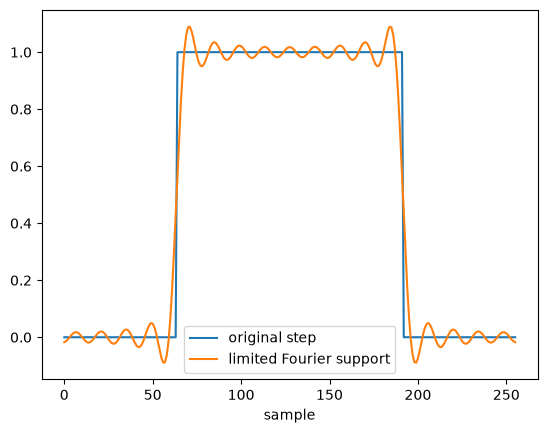

In [2]:
step=np.zeros(256); step[64:192]=1
spectrum=np.fft.rfft(step); limited=spectrum.copy(); limited[18:]=0
ringing=np.fft.irfft(limited,n=len(step))
print('ringing minimum/maximum:',ringing.min(),ringing.max())
assert ringing.min()<-.03 and ringing.max()>1.03
wrong=np.abs(ringing)
assert not np.allclose(wrong,ringing)
plt.plot(step,label='original step'); plt.plot(ringing,label='limited Fourier support')
plt.xlabel('sample'); plt.legend(); plt.show()


## Check and explain

Rank2 improves known-truth MSE relative to the noisy matrix; rank1 loses needed structure. Fourier truncation produces values below0 and above1 near edges. Those are operator effects, not additional tissue classes or proof that an MRI volume contains negative physical magnitude.

## Deliberately wrong method

Choosing the smallest rank that makes an image smooth can remove the signal needed for diffusion modeling. Taking absolute values of ringing conceals one lobe but is not an artifact-correction model. Neither error is fixed by a successful array-shape check.

## Transfer to an actual dataset or tool — guided assignment

Follow DIPY’s MP-PCA and Gibbs examples, reading their data/acquisition requirements before running. Then complete Oxford FDT’s TOPUP/EDDY inspection using course data and installed FSL. Keep a processing-order diagram, input/output hashes, outlier/movement reports and rotated gradients. Compare residual images and anatomical edges, and record what was not corrected. These full external practicals need additional dependencies and data and are deliberately separate from the offline core.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why can interpolation affect denoising assumptions? **Answer:** it changes noise correlations and sampling properties.
2. Is rank2 always correct? **Answer:** no; it is known only because we constructed this matrix. A real estimator must justify its model and inspect lost information.
